# House Price Prediction using Multiple Linear Regression

## Objective
Build a Multiple Linear Regression model to predict house prices using:
- GrLivArea (Above Ground Living Area)
- BedroomAbvGr (Number of Bedrooms)
- FullBath (Number of Full Bathrooms)

Target Variable:
- SalePrice

In [ ]:
# Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Load the dataset

df = pd.read_csv('/content/train (1).csv')

In [ ]:
# Display the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (1460, 81)


In [ ]:
# Display all column names
print(df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
# Check for missing values in the selected columns

df[['GrLivArea',
    'BedroomAbvGr',
    'FullBath',
    'SalePrice']].isnull()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
1455,False,False,False,False
1456,False,False,False,False
1457,False,False,False,False
1458,False,False,False,False


## Select Features and Target

In [ ]:
# Select input features
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

# Select target variable
y = df['SalePrice']

## Split the Dataset

In [ ]:
# into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train the Model

In [ ]:
# Create and train the model

model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# Predict house prices

y_pred = model.predict(X_test)

# Display the first predicted price
print(y_pred[0])

113410.67255297581


## Compare Actual and Predicted Values

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
892,154500,113410.672553
1105,325000,305081.877759
413,115000,135904.785630
522,159000,205424.675641
1036,315500,227502.683490
614,75500,121157.480796
218,311500,205577.980566
1160,146000,183787.203783
649,84500,121157.480796
887,135500,147219.222332


In [ ]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 35788.061292436294
Mean Squared Error : 2806426667.247853
Root Mean Squared Error : 52975.71771338122
R² Score : 0.6341189942328371


In [ ]:
# Display the intercept and coefficients

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 52261.74862694461
Coefficients: [   104.02630701 -26655.16535734  30014.32410896]


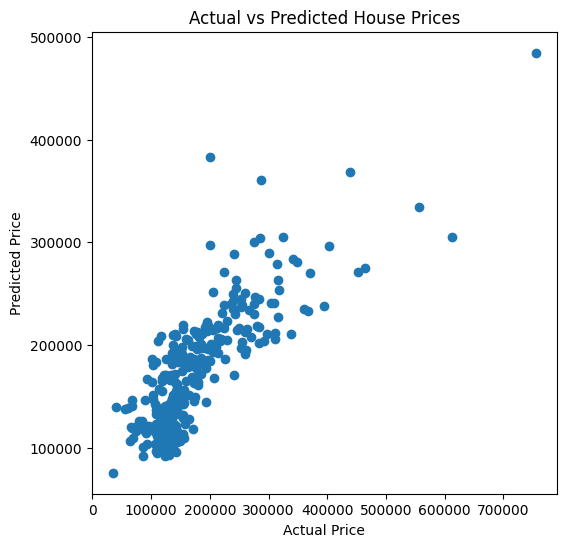

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Conclusion

A Multiple Linear Regression model was built using three features:
- GrLivArea
- BedroomAbvGr
- FullBath

The model was evaluated using MAE, MSE, RMSE and R² Score.

The model achieved an R² Score of approximately **0.63**, indicating that these three features explain a good portion of the variation in house prices. Including additional relevant features from the dataset could further improve the model's performance.